In [21]:
import numpy as np
import matplotlib.pyplot as plt
import os
os.makedirs("figures",exist_ok = True)

In [22]:
mu_Cox_WL = 1e-3 # combined fabrication parameter (A/V^2) (μ × Cox × (W/L))
V_th = 0.7 # threshold voltage (V) (minimum voltage to form the channel connecting the source and drain)

In [23]:
V_DS = np.linspace(0, 5, 1000) # drain source voltage from 0 to 5V (x-axis)
V_GS_values = [1.0, 2.0, 3.0, 4.0, 5.0] # 5 different gate voltages to plot

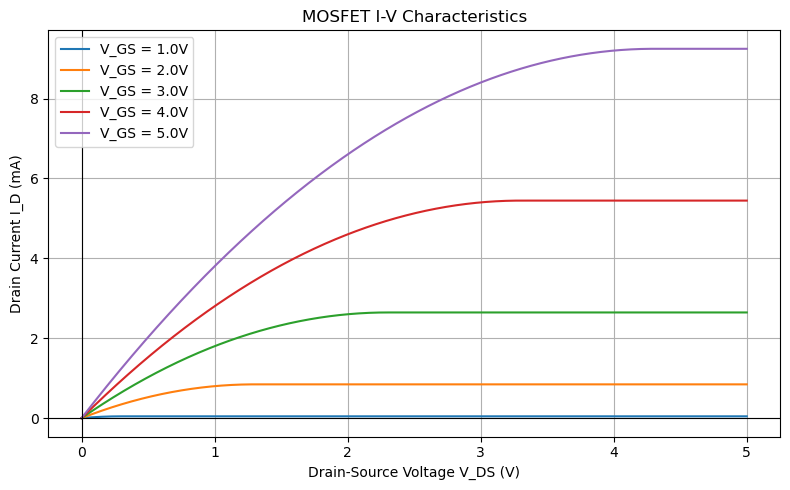

In [24]:
plt.figure(figsize = (8,5))

for V_GS in V_GS_values:
    I_D = np.zeros(len(V_DS)) # create an array of zeros as the length as V_DS

    for i, vds in enumerate(V_DS):
        if V_GS <= V_th:
            #below the threshold voltage - no channel - transistor is off
            I_D[i] = 0

        elif vds < V_GS - V_th:
            #linear region - channel exists - current rises with V_DS
            I_D[i] = mu_Cox_WL * ((V_GS - V_th) * vds - vds**2 / 2 )

        else:
            # saturation region - channel exists - current rises with V_GS
            I_D[i] = 0.5 * mu_Cox_WL * (V_GS - V_th) **2

    plt.plot(V_DS, I_D * 1000, label =f"V_GS = {V_GS}V")

plt.xlabel("Drain-Source Voltage V_DS (V)")
plt.ylabel("Drain Current I_D (mA)")
plt.title("MOSFET I-V Characteristics")
plt.axhline(0, color = 'black', linewidth = 0.8)
plt.axvline(0, color = 'black', linewidth = 0.8)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("figures/mosfet_curves.png", dpi = 150)
plt.show()